Email coarse scan image for status update

In [15]:
import sys, os, time
sys.path.append('/home/beams/USERBNP/scripts/')
import pandas as pd
import collections
import h5py
import matplotlib.pyplot as plt
import numpy as np
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.image import MIMEImage

def nextScanName(scname):
    scnumber = int(scname[7:11])
    nextsc_str = str(scnumber+1).zfill(4)
    nextscname = scname
    nextscname = scname.replace(scname[7:11], nextsc_str)
    return nextscname


def getElmMap(fname, elm):
    elmmap = []
    with h5py.File(fname, 'r') as dat:
        xrfdata = dat['/MAPS/XRF_roi'][:]
        try:
            ch_idx = dat['/MAPS/channel_names'][:].astype('U13').tolist().index(elm)
            elmmap = xrfdata[ch_idx,:,:]
            x_pos = dat['/MAPS/x_axis'][:]
            y_pos = dat['/MAPS/y_axis'][:]
            extrpvs = dat['/MAPS/extra_pvs'][:]
            h5pv = extrpvs[0,:].astype('U13').tolist()
            pv_index = h5pv.index('9idbTAU:SM:ST')
            theta = float(extrpvs[1,pv_index])
        except:
            raise ValueError('Invalid element! %s is not in channel list'%(elm))
    return elmmap, x_pos, y_pos, theta


def getRecentCoarseImgPath(userdir, ctime = None):
    imgProgpath = os.path.join(userdir, 'imgProg')
    imgfiles = os.listdir(imgProgpath)
    fileTime_dict = collections.defaultdict(list)
    for img_ in imgfiles:
        scan_path = os.path.join(imgProgpath, img_)
        file_mod_time = os.stat(scan_path).st_mtime
        fileTime_dict['time'].append(file_mod_time)
        fileTime_dict['fpath'].append(scan_path)
        
    f_idx = fileTime_dict['time'].index(max(fileTime_dict['time']))
    f_path = fileTime_dict['fpath'][f_idx]
    
    if (ctime is not None) & (ctime == max(fileTime_dict['time'])):
        print(int(ctime), int(max(fileTime_dict['time'])), len(imgfiles))
        return -1
    else:
        return f_path


def sendUpdate(userdir, recipients, ctime = None):
    # latest coarse scan
    img_path = getRecentCoarseImgPath(userdir, ctime = ctime)
    if img_path != -1:
        sc_num = img_path.split('/')[-1]

        me = "yluo89@anl.gov"

        # Create message container - the correct MIME type is multipart/alternative.
        msg = MIMEMultipart('')
        msg['Subject'] = "Scan Status Update: %s"%(sc_num)
        msg['From'] = me
        msg['To'] = (', ').join(recipients.split(','))

        # Create the body of the message (a plain-text and an HTML version).
        text = "Status update of the coarse_fine batch scan.\n"
        email_body = """\
        <html>
          <head></head>
          <body>
            <p>Hi!<br>
               Status Update <br>
               Coarse scan finished <br>
               <img src='cid:image1' alt='image' style="display: block;margin: auto;width: 100%;">
            </p>
          </body>
        </html>
        """

        # Read and encode the image
        img_data = open(img_path, 'rb').read()
        image = MIMEImage(img_data)
        image.add_header('Content-ID', '<image1>')
        msg.attach(image)

        # Send the message via local SMTP server.
        s = smtplib.SMTP('localhost')
        # sendmail function takes 3 arguments: sender's address, recipient's address
        # and message to send - here it is sent as one string.
        s.sendmail(me, msg['To'], msg.as_string())
        s.quit()
        print('Sending update of %s\n'%(img_path))
        return os.stat(img_path).st_mtime
    else:
        print('Latest update sent\n')
        return ctime

In [16]:
userdir = '/mnt/micdata1/bnp/2021-1/Isaure/'
ctime = time.time()
recipents = 'yluo89@anl.gov'
while 1:
    ctime = sendUpdate(userdir, recipents, ctime = ctime)
    time.sleep(60)

Sending update of /mnt/micdata1/bnp/2021-1/Isaure/imgProg/bbox_bnp_fly0175.mda.png

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 1616825483 22
Latest update sent

1616825483 16168

1616834657 1616834657 27
Latest update sent

1616834657 1616834657 27
Latest update sent

1616834657 1616834657 27
Latest update sent

Sending update of /mnt/micdata1/bnp/2021-1/Isaure/imgProg/bbox_bnp_fly0187.mda.png

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 1616836443 28
Latest update sent

1616836443 16168

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828 1616846828 32
Latest update sent

1616846828

KeyboardInterrupt: 

/APSshare/anaconda3/x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:19: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.


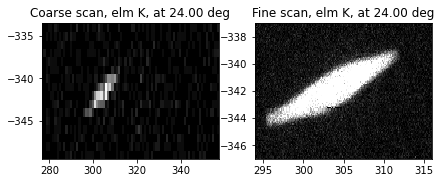

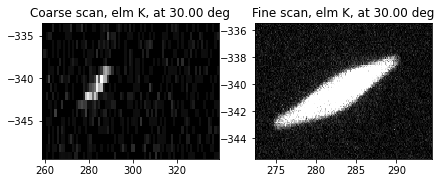

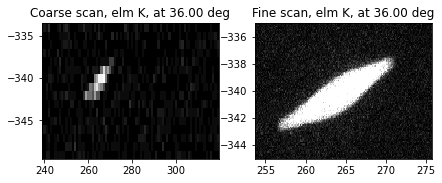

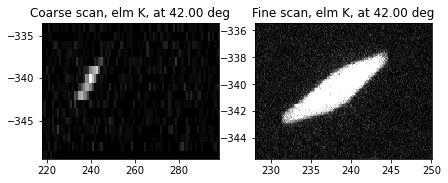

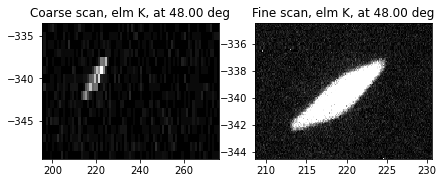

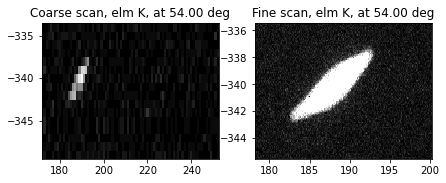

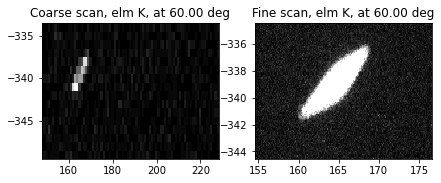

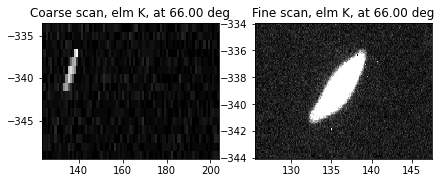

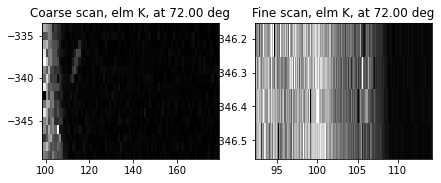

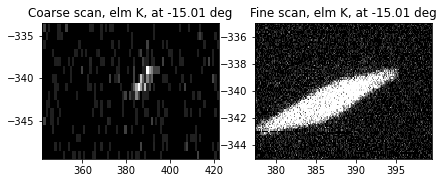

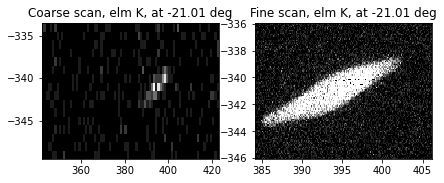

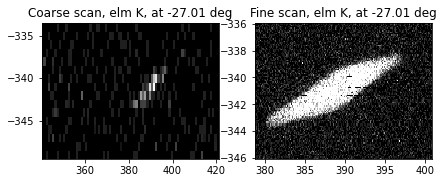

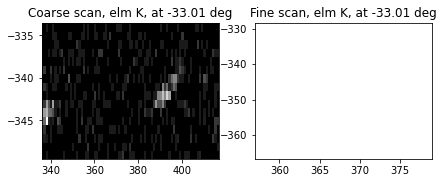

In [72]:
userdir = '/mnt/micdata1/bnp/2021-1/Isaure/'
logpath = os.path.join(userdir,'log.txt')
sc_dic = collections.defaultdict(list)
elm = 'K'
with open(logpath, 'r') as f:
    for l in f:
        if 'Extract ROI corr' in l:
            s = l.split(' ')
            sc = s[-1].replace(':\n','.h5')
            nextsc = nextScanName(sc)
            cfile = os.path.join(userdir, 'img.dat/%s'%(sc))
            ffile = os.path.join(userdir, 'img.dat/%s'%(nextsc))
            if os.path.exists(ffile):
                coarse = getElmMap(cfile, elm)
                fine = getElmMap(ffile, elm)
                fig, axes = plt.subplots(1,2,figsize=(7,2.5))
                vmax = np.nanmean(fine[0]) + 2 * np.nanstd(fine[0])
                axes[0].pcolor(coarse[1], coarse[2], coarse[0], cmap='gray', shading='nearest')
                axes[1].pcolor(fine[1], fine[2], fine[0], cmap='gray', shading='auto', vmax = vmax)
                axes[0].set_title('Coarse scan, elm %s, at %.2f deg'%(elm, coarse[-1]))
                axes[1].set_title('Fine scan, elm %s, at %.2f deg'%(elm, fine[-1]))
#             fig = plt.figure()
#             plt.pcolor(x_pos, y_pos, elmmap, cmap='gray')(m1[0])

